In [1]:
import pandas as pd
df = pd.read_csv('/content/customer_support_tickets_csv.csv')
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [2]:
df.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [3]:
df['Ticket Type'].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


In [4]:
df['Ticket Priority'].value_counts()

,count
Ticket Priority,
Medium,2192
Critical,2129
High,2085
Low,2063


In [5]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_description'] = df['Ticket Description'].apply(clean_text)
df[['Ticket Description', 'clean_description']].head()

,Ticket Description,clean_description
0,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
1,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
2,I'm facing a problem with my {product_purchase...,im facing a problem with my productpurchased t...
3,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
4,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['clean_description'])

print("Shape of our text data:", X.shape)

Shape of our text data: (8469, 1000)


In [7]:
from sklearn.preprocessing import LabelEncoder

category_encoder = LabelEncoder()
y_category = category_encoder.fit_transform(df['Ticket Type'])

print("Categories:", category_encoder.classes_)

Categories: ['Billing inquiry' 'Cancellation request' 'Product inquiry'
 'Refund request' 'Technical issue']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_category, test_size=0.2, random_state=42)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 6775
Testing size: 1694


In [9]:
from sklearn.linear_model import LogisticRegression

category_model = LogisticRegression(max_iter=1000)
category_model.fit(X_train, y_train)

print("Category classification model trained successfully!")

Category classification model trained successfully!


In [10]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_category = category_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_category)
print(f"Category Classification Accuracy: {accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_category, target_names=category_encoder.classes_))

Category Classification Accuracy: 19.78%

Detailed Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.12      0.14       357
Cancellation request       0.17      0.17      0.17       327
     Product inquiry       0.19      0.21      0.20       316
      Refund request       0.21      0.26      0.23       345
     Technical issue       0.23      0.23      0.23       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



In [11]:
priority_encoder = LabelEncoder()
y_priority = priority_encoder.fit_transform(df['Ticket Priority'])

print("Priority levels:", priority_encoder.classes_)

Priority levels: ['Critical' 'High' 'Low' 'Medium']


In [12]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X, y_priority, test_size=0.2, random_state=42)

priority_model = LogisticRegression(max_iter=1000)
priority_model.fit(X_train_p, y_train_p)

print("Priority classification model trained successfully!")

Priority classification model trained successfully!


In [13]:
y_pred_priority = priority_model.predict(X_test_p)

priority_accuracy = accuracy_score(y_test_p, y_pred_priority)
print(f"Priority Classification Accuracy: {priority_accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test_p, y_pred_priority, target_names=priority_encoder.classes_))

Priority Classification Accuracy: 27.51%

Detailed Report:
              precision    recall  f1-score   support

    Critical       0.27      0.28      0.27       411
        High       0.27      0.29      0.28       409
         Low       0.27      0.27      0.27       415
      Medium       0.29      0.26      0.28       459

    accuracy                           0.28      1694
   macro avg       0.28      0.28      0.28      1694
weighted avg       0.28      0.28      0.28      1694



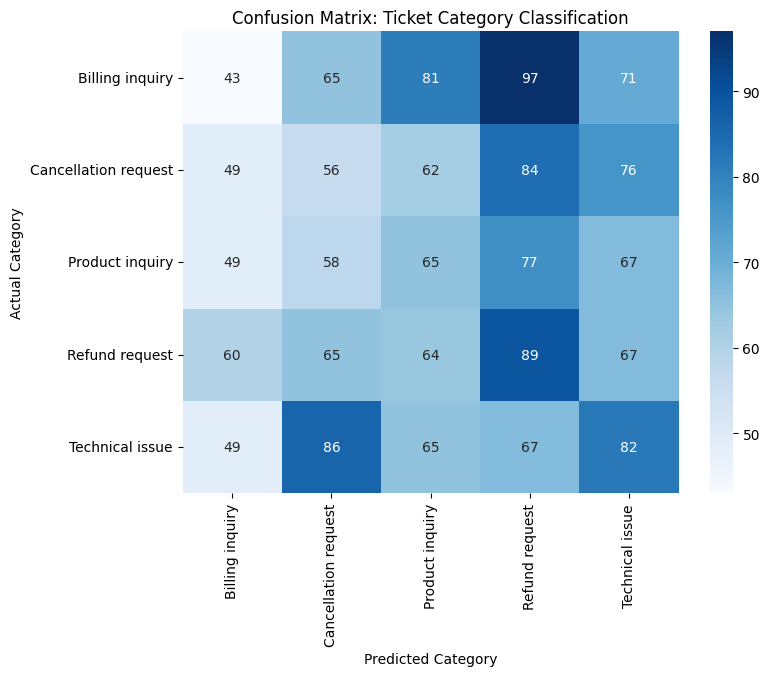

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_category)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=category_encoder.classes_,
            yticklabels=category_encoder.classes_)
plt.title('Confusion Matrix: Ticket Category Classification')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

## Business Summary

This project builds a Machine Learning system to automatically classify customer support tickets by category (Billing, Technical Issue, Refund, etc.) and predict their priority level (Low, Medium, High, Critical), using TF-IDF text vectorization and Logistic Regression.

**Business Context:** This system was built for a hypothetical SaaS or e-commerce support team handling high ticket volume, aiming to reduce manual sorting time and speed up response to urgent issues.

**Key Findings:**
- Category classification accuracy: approx. 19.78%
- Priority classification accuracy: approx. 27.51%
- Both results are close to random-chance baseline (20% for 5 categories, 25% for 4 priority levels), indicating the model struggles to find strong distinguishing patterns in the ticket text.
- The confusion matrix shows predictions scattered fairly evenly across all categories rather than concentrated correctly along the diagonal, confirming weak text signal.

**Root Cause Analysis:** On inspection, this dataset's ticket descriptions are largely templated (e.g., "I'm having an issue with the {product_purchased}. Please assist.") rather than free-form customer writing. This means the actual wording carries very little unique information to distinguish one category or priority from another — the text is nearly identical across tickets regardless of their true label.

**What This Means for a Real Business:**
- This highlights a critical, real-world lesson in applied ML: **model performance is only as good as the signal available in the data.** A production system would need genuinely free-form ticket text (real customer complaints, not templated placeholders) to learn meaningful patterns.
- In practice, a support team should combine text classification with structured metadata (e.g., product type, customer tier, order value) to significantly improve category and priority prediction.
- Even an imperfect model like this can still add value by flagging tickets for manual review rather than fully automating triage, until a stronger dataset is available.

**Recommendation:** For future iterations, use a dataset with authentic, varied customer-written ticket text, and consider combining text features with structured business metadata for higher accuracy.